# Notebook 1: Exploratory Data Analysis

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from model_functions import dataFullTransformer

In [2]:
df = pd.read_csv('data/zbiór_2.csv')

In [6]:
df.head()

,szczegolnaFormaPrawna_Symbol,formaWlasnosci_Symbol,pkdKod,wsk_liczba_dni_istnienia,Aktywa,Aktywa_trwale,Wartosci_niematerialne_prawne,Wartosc_firmy,Rzeczowe_aktywa_trwale,Srodki_trwale,...,wsk_struktura_kap_wlasnego_s_1,wsk_struktura_kap_wlasnego_s_2,wsk_zadluzenia,wsk_zob_dlugoterminowe_aktywa_rzeczowe,wsk_zob_oprocentowanych,wsk_zob_oprocentowanych_aktywa_rzeczowe,wsk_struktura_kap_obcego_s,wsk_zob_s_aktywa_rzeczowe,wsk_fin_majatku_kapitalem,default
0,117,224,4120,1501,667091.16,87750.43,0.0,0.0,87750.43,87750.43,...,0.063976,0.080032,14.630797,0.000000,0.000000,0.000000,0.936024,0.735403,-0.077800,1
1,117,214,6820,1570,180157.00,0.00,0.0,0.0,0.00,0.00,...,0.993339,0.993339,0.006706,0.006661,0.000000,0.000000,0.006661,0.006661,0.993339,1
2,117,0,4646,1952,297880.73,43721.66,0.0,0.0,43721.66,43721.66,...,0.199896,0.245042,4.002593,0.500066,0.500066,0.500066,0.800104,0.615868,0.062259,1
3,117,214,7010,1361,11599.10,100.00,0.0,0.0,0.00,0.00,...,0.655146,4.095093,0.526378,0.000000,0.344854,0.344854,0.344854,-0.495163,0.652147,1
4,117,216,6201,2170,45883.96,1847.82,0.0,0.0,0.00,0.00,...,0.309014,0.309014,2.236101,0.690986,0.000000,0.000000,0.690986,0.690986,0.280019,1


In [7]:
df.info()
describe = df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Columns: 220 entries, szczegolnaFormaPrawna_Symbol to default
dtypes: float64(213), int64(5), object(2)
memory usage: 5.0+ MB


e:\Programy\Anaconda\envs\interpretability\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


# Uzupełnienie braków

In [3]:
y = df["default"].copy()
df = df.drop(columns='default')

In [4]:
transformer = dataFullTransformer(df.columns)

In [5]:
numeric_pipe = transformer.transformers[1][1]
numeric_pipe

,steps,"[('replaceInf', ...), ('replace0missings', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function rep...00215DF67AB60>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,'one-to-one'
,kw_args,None


In [11]:
numeric_pipe.get_params

<bound method Pipeline.get_params of Pipeline(steps=[('replaceInf',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<function replaceInf at 0x000002209D1EA660>)),
                ('replace0missings', ZeroToNaNTransformer()),
                ('removeEmptyColumns',
                 DropConstantFeatures(missing_values='include')),
                ('removeOutliers1', OutliersClipper()),
                ('removeLowVariance1', VarianceThreshold(threshold=0.5)),
                ('iterativeIm...
                ('financial_engineering', FinancialFeatureEngineer()),
                ('dataClip',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<function clip at 0x000002209D1EA520>)),
                ('removeLowVariance2', VarianceThreshold(threshold=0.5)),
                ('standarization', StandardScaler()),
                ('dropCorrelated', DropCorrelatedFeatures(thresh

In [6]:
numeric_pipe.set_params(standarization = 'passthrough', dropCorrelated = 'passthrough', signCorrelationFlip='passthrough')

,steps,"[('replaceInf', ...), ('replace0missings', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function rep...00215DF67AB60>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,'one-to-one'
,kw_args,None


In [7]:
transf_arr = transformer.fit_transform(df, y)
df = pd.DataFrame(transf_arr, columns=transformer.get_feature_names_out())
df = pd.concat([df, y], axis=1)

In [14]:
df.describe()

,numeric_pipeline__wsk_liczba_dni_istnienia,numeric_pipeline__Aktywa,numeric_pipeline__Aktywa_trwale,numeric_pipeline__Wartosci_niematerialne_prawne,numeric_pipeline__Wartosc_firmy,numeric_pipeline__Rzeczowe_aktywa_trwale,numeric_pipeline__Srodki_trwale,numeric_pipeline__Naleznosci_dlugoterminowe,numeric_pipeline__Inwestycje_dlugoterminowe,numeric_pipeline__Rozliczenia_miedzyokresowe_dlugie,...,numeric_pipeline__Aktywa_per_day,numeric_pipeline__Zysk_netto_per_day,numeric_pipeline__Kapital_wlasny_per_day,numeric_pipeline__Zysk_netto_x_Kapital_wlasny,numeric_pipeline__Zysk_netto_div_Kapital_wlasny,numeric_pipeline__Aktywa_x_Kapital_wlasny,numeric_pipeline__Aktywa_div_Kapital_wlasny,symbols_pipeline__pkdKod,symbols_pipeline__formaWlasnosci_Symbol,default
count,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,...,3000.000000,3000.000000,3000.000000,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000
mean,3986.729833,2.630797e+06,1.314671e+06,1.259096e+05,1.244043e+05,8.253267e+05,7.455501e+05,2.083722e+05,4.757001e+05,8.494857e+04,...,708.579534,-4.464917,348.129932,-4.835410e+10,-0.168472,1.395119e+13,7.108433,-0.013219,-0.010094,0.129667
std,2745.845748,4.559580e+06,3.149789e+06,2.535169e+05,2.561678e+05,2.154019e+06,1.915329e+06,2.075609e+05,3.147032e+06,1.797780e+05,...,1406.241893,905.358976,730.890157,1.354440e+13,3.093601,3.892188e+13,60.173886,0.250738,0.165026,0.335992
min,1179.000000,9.280000e+00,-5.828625e+05,-8.738922e+05,-8.748835e+05,-1.000000e+06,-1.000000e+06,-1.178244e+05,-1.000000e+06,-4.074412e+05,...,0.000908,-46271.816455,0.000908,-6.998450e+14,-94.590560,8.611840e+01,0.026339,-0.191037,-0.661040,0.000000
25%,1795.750000,1.034833e+05,5.814182e+04,6.510856e+04,4.701243e+04,4.604353e+04,6.540626e+04,1.436284e+05,-2.013567e+05,1.846608e+04,...,34.609015,0.000000,17.408032,0.000000e+00,0.000000,5.751066e+09,1.102973,-0.182858,-0.058223,0.000000
50%,2812.500000,5.493858e+05,1.867946e+05,8.337260e+04,7.672746e+04,1.490577e+05,1.683396e+05,1.501251e+05,-8.111311e+04,2.812484e+04,...,173.860892,0.000000,79.213101,0.000000e+00,0.000000,1.423516e+11,1.519095,-0.072154,-0.058223,0.000000
75%,5696.250000,2.617205e+06,5.388010e+05,9.801191e+04,1.372307e+05,3.693715e+05,3.547716e+05,1.734829e+05,1.540190e+05,7.192364e+04,...,681.014008,21.554202,310.534160,4.299964e+10,0.141772,2.967913e+12,2.678963,0.020775,-0.058223,0.000000
max,10215.150000,1.722947e+07,1.452328e+07,2.523592e+06,2.636254e+06,1.154937e+07,1.069016e+07,2.544198e+06,2.803480e+07,1.900000e+06,...,13233.081576,775.172343,7656.960428,9.944989e+12,16.085478,1.726903e+14,2032.980322,7.867489,0.444590,1.000000


In [15]:
missing_values = df.isnull().sum()
print("🔸 Liczba braków:\n", missing_values[missing_values > 0])

🔸 Liczba braków:
 Series([], dtype: int64)


In [16]:
unique_counts = df.nunique().sort_values()
print("🔸 Liczba unikalnych wartości:\n", unique_counts)
print("🔸 Liczba duplikatów:", df.duplicated().sum())

🔸 Liczba unikalnych wartości:
 default                                                                    2
numeric_pipeline__Inne_zobowiazania_fin_krotkoterminowe                    2
numeric_pipeline__Inne_zobowiazania_fin_krotkoterminowe_sqrt               2
numeric_pipeline__Inne_zobowiazania_fin_krotkoterminowe_squared            2
numeric_pipeline__koszty_ogolnego_zarzadu_sqrt                             3
                                                                        ... 
numeric_pipeline__Ujemna_wartosc_firmy_to_assets                        3000
numeric_pipeline__Ujemna_wartosc_firmy_squared                          3000
numeric_pipeline__Ujemna_wartosc_firmy_sqrt                             3000
numeric_pipeline__Naleznosci_dostaw_uslug_pozostale_sadowe_to_assets    3000
numeric_pipeline__wsk_rent_operacyjna_to_assets                         3000
Length: 747, dtype: int64
🔸 Liczba duplikatów: 0


Widać, że w pewna część zmiennych jest ze sobą mocno skorelowanych

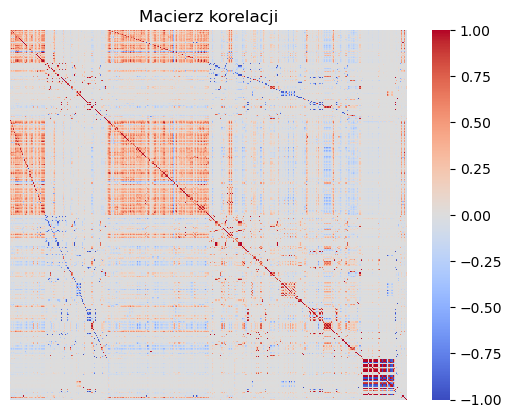

In [17]:
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, yticklabels=False, xticklabels=False)
plt.title("Macierz korelacji")
plt.show()

In [8]:
threshold = 0.7
corr = df.corr(numeric_only=True).abs()

cols_to_drop = set()
for i in range(len(corr.columns)):
    for j in range(i):  # tylko dolna połowa + diagonalę pomijamy
        col1 = corr.columns[i]
        col2 = corr.columns[j]
        if corr.loc[col1, col2] > threshold:
            # jeśli żadna z kolumn jeszcze nie jest oznaczona do usunięcia
            if col1 not in cols_to_drop and col2 not in cols_to_drop:
                # wybieramy jedną do usunięcia - np. drugą
                cols_to_drop.add(col2)

print("Kolumny do usunięcia, aby ograniczyć silne korelacje:")
print(cols_to_drop)

Kolumny do usunięcia, aby ograniczyć silne korelacje:
{'numeric_pipeline__wsk_amortyzacja_to_assets', 'numeric_pipeline__wsk_zysk_op_zobowiazania', 'numeric_pipeline__wsk_udzial_zob_biez_aktywa_2', 'numeric_pipeline__log_wsk_zast_kapitalu_wlasnego', 'numeric_pipeline__wsk_zysk_ebitda_3_squared', 'numeric_pipeline__wsk_ROE_squared', 'numeric_pipeline__wsk_plynnosc_szybka_2', 'numeric_pipeline__wsk_zwrot_aktywa_mat_sqrt', 'numeric_pipeline__wsk_plynnosc_biez_2_squared', 'numeric_pipeline__wsk_koszty_fin_przychody_squared', 'numeric_pipeline__wsk_marza_ebitda_1', 'numeric_pipeline__wsk_poziom_kosztow_operacyjnych', 'numeric_pipeline__wsk_sytuacji_fin', 'numeric_pipeline__log_dotacje', 'numeric_pipeline__Inne_rozliczenia_miedzyokresowe_squared', 'numeric_pipeline__wsk_ebitda_koszty_odsetkowe_1_to_assets', 'numeric_pipeline__amortyzacja_squared', 'numeric_pipeline__wsk_rotacja_naleznosci_squared', 'numeric_pipeline__wsk_zast_kapitalu_podstawowego_squared', 'numeric_pipeline__wsk_ebitda_zobo

In [9]:
cols_to_drop = [el for el in cols_to_drop]

In [20]:
len(cols_to_drop)

587

In [10]:
df = df.drop(columns=cols_to_drop)

In [22]:
df.shape

(3000, 160)

Dużo lepiej

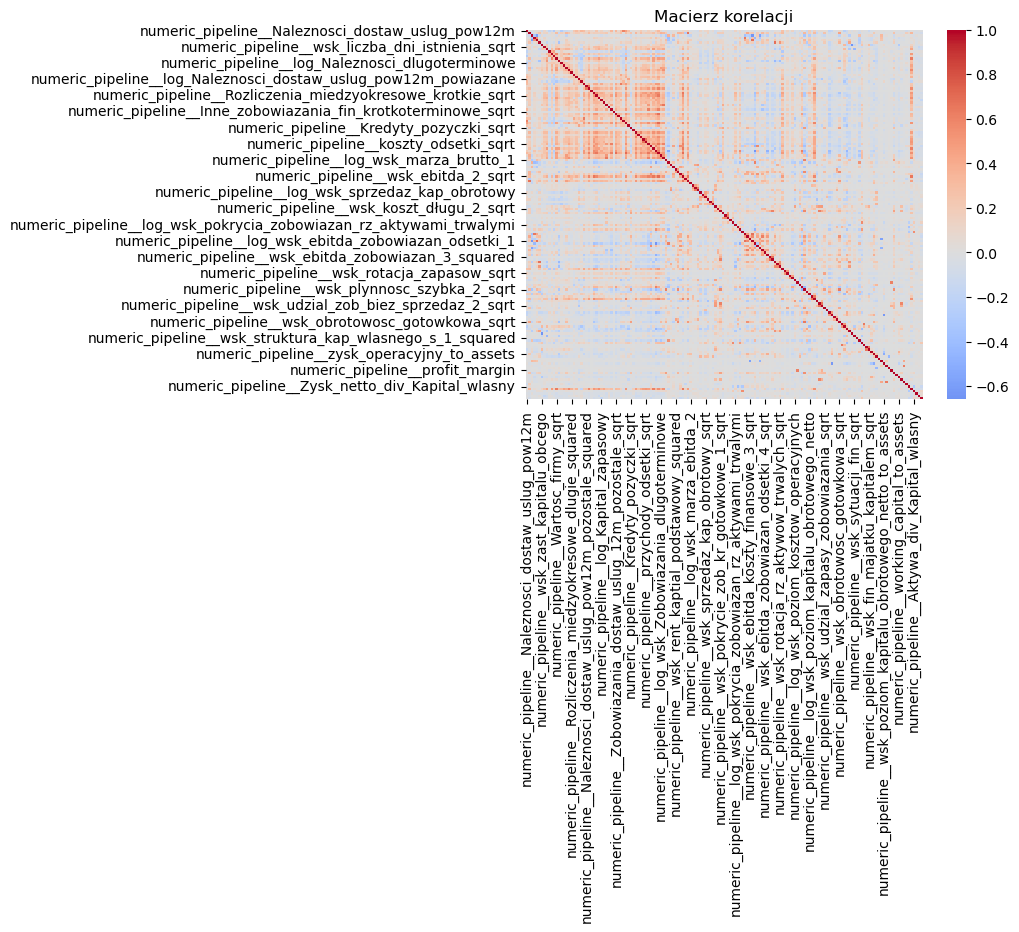

In [23]:
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Macierz korelacji")
plt.show()

<Axes: xlabel='default', ylabel='Count'>

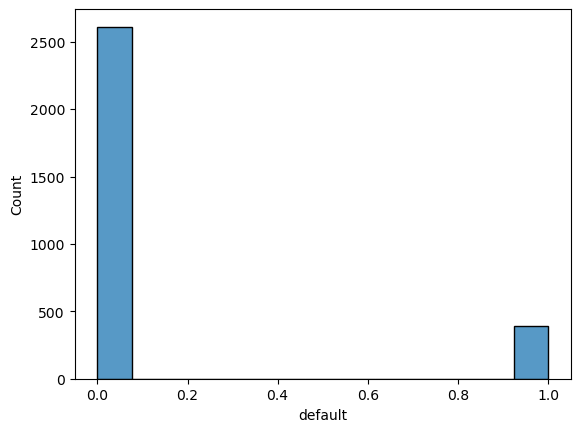

In [24]:
sns.histplot(df['default'])

Potencjalne outliery - tam gdzie maks jest cztery rzędy wielkości większy niż 95 kwantyl

In [11]:
eps = 1e-4

cols_with_possible_outliers = []

for col in df.select_dtypes(include='number').columns:
    col_max = df[col].max() + eps
    col_min = df[col].min() + eps
    q95 = df[col].quantile(0.95) + eps
    q05 = df[col].quantile(0.05) + eps
    
    # pomijamy kolumny, które są w przedziale (0,1)
    if df[col].max() <= 1 and df[col].min() >= 0:
        continue
    
    # sprawdzamy warunek
    if col_max >= q95*10000 or col_min*10000 <= q05:
        cols_with_possible_outliers.append(col)

In [26]:
len(cols_with_possible_outliers)

42

In [12]:
for col in cols_with_possible_outliers:
    q95 = df[col].quantile(0.97)
    q05 = df[col].quantile(0.03)
    df[col] = df[col].clip(lower=q05, upper=q95)

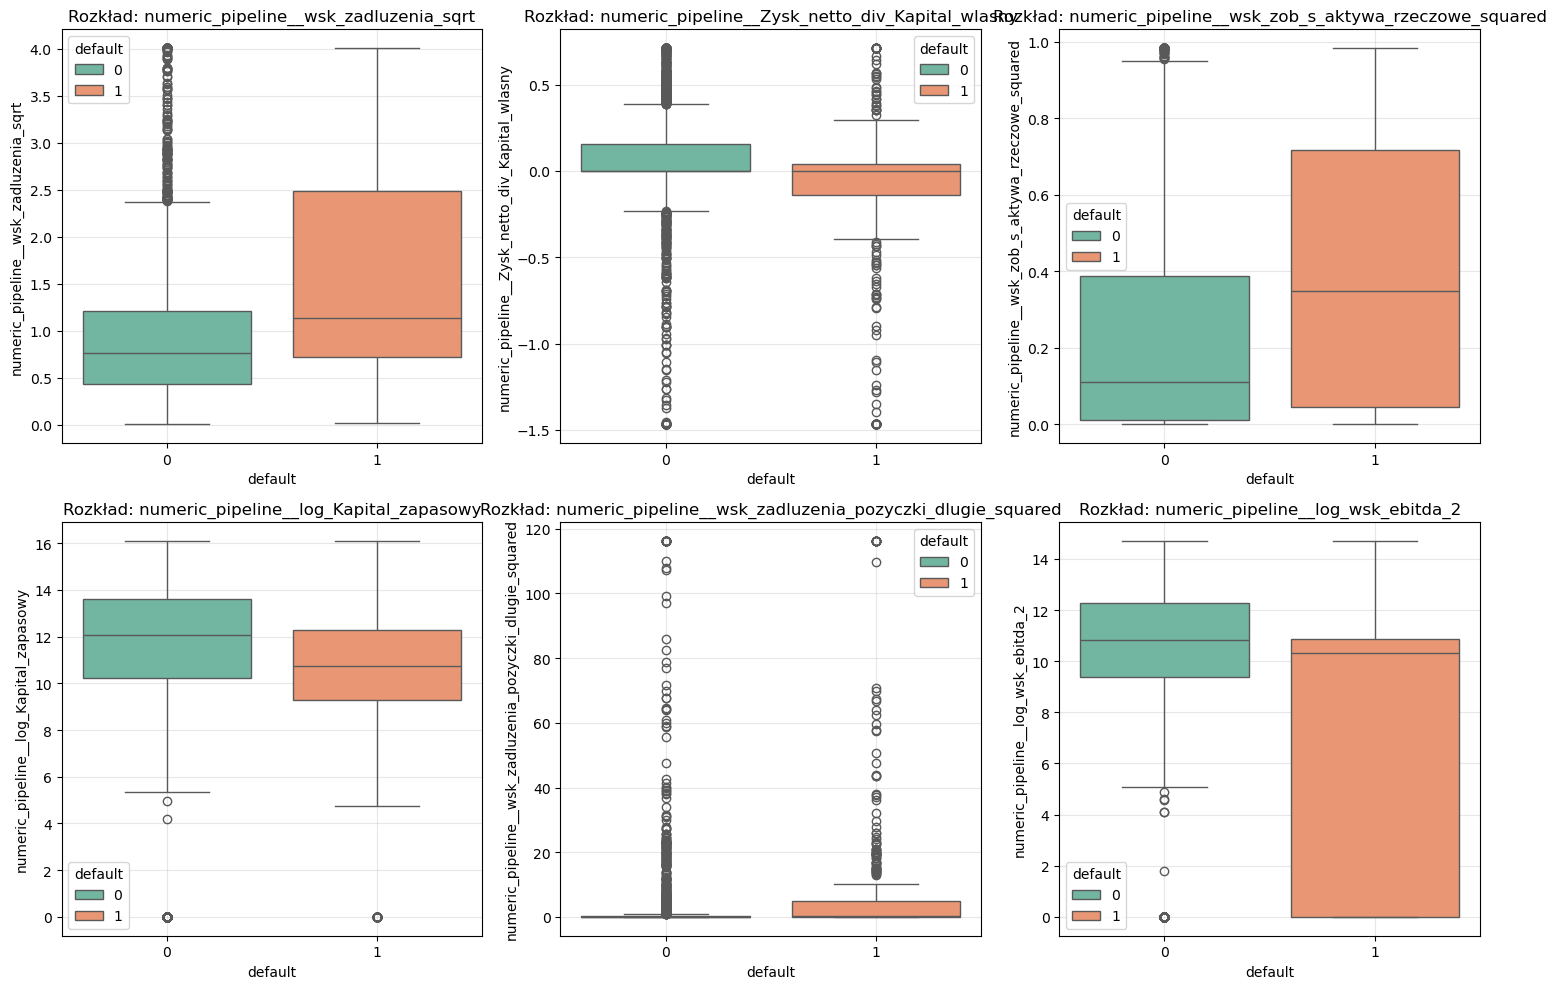

In [28]:
# Wybieramy np. 6 cech o najwyższej korelacji z 'default'
top_corr_features = df.corr()['default'].abs().sort_values(ascending=False).index[1:7]

plt.figure(figsize=(15, 10))
for i, col in enumerate(top_corr_features):
    plt.subplot(2, 3, i+1)
    # Boxplot jest świetny do pokazywania różnic w medianie i rozstępie
    sns.boxplot(x='default', y=col, data=df, hue='default', palette="Set2")
    plt.title(f'Rozkład: {col}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Top 10 cech wg Mutual Information:
default                                                       0.385919
numeric_pipeline__Zysk_netto_div_Kapital_wlasny               0.029802
numeric_pipeline__equity_to_liabilities                       0.029363
numeric_pipeline__Kapital_wlasny_to_assets                    0.025499
numeric_pipeline__Aktywa_div_Kapital_wlasny                   0.024640
numeric_pipeline__log_zysk_netto                              0.024246
numeric_pipeline__zysk_operacyjny_to_assets                   0.022903
numeric_pipeline__log_wsk_struktura_kap_wlasnego_s_2          0.021876
numeric_pipeline__current_ratio                               0.021666
numeric_pipeline__log_wsk_poziom_kapitalu_obrotowego_netto    0.021581
dtype: float64


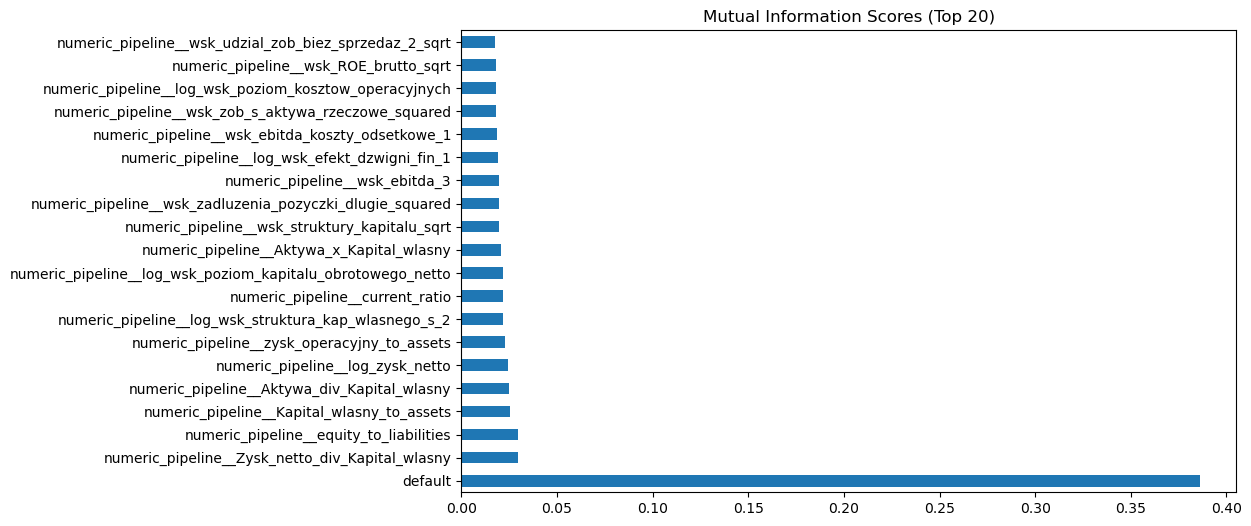

In [29]:
from sklearn.feature_selection import mutual_info_classif

# Obliczenie MI (może chwilę potrwać)
mi_scores = mutual_info_classif(df, y, random_state=42)

# Stworzenie serii pandas dla łatwiejszego czytania
mi_series = pd.Series(mi_scores, index=df.columns).sort_values(ascending=False)

print("Top 10 cech wg Mutual Information:")
print(mi_series.head(10))

# Wykres
plt.figure(figsize=(10, 6))
mi_series.head(20).plot(kind='barh')
plt.title("Mutual Information Scores (Top 20)")
plt.show()

## Importance Value

Rozpoczynam obliczanie IV dla 154 cech...

--- TOP 20 CECH WG INFORMATION VALUE (IV) ---


,Feature,IV
0,numeric_pipeline__Aktywa_div_Kapital_wlasny,0.468967
1,numeric_pipeline__Kapital_wlasny_to_assets,0.468967
2,numeric_pipeline__equity_to_liabilities,0.440745
3,numeric_pipeline__wsk_struktura_kap_wlasnego_s_1_squared,0.395960
4,numeric_pipeline__wsk_struktury_kapitalu_sqrt,0.378834
5,numeric_pipeline__Zysk_netto_x_Kapital_wlasny,0.377591
6,numeric_pipeline__wsk_zadluzenia_sqrt,0.377549
7,numeric_pipeline__wsk_ogolnego_zadluzenia_2_sqrt,0.376193
8,numeric_pipeline__log_wsk_struktura_kap_wlasnego_s_2,0.336199
9,numeric_pipeline__Aktywa_x_Kapital_wlasny,0.312788


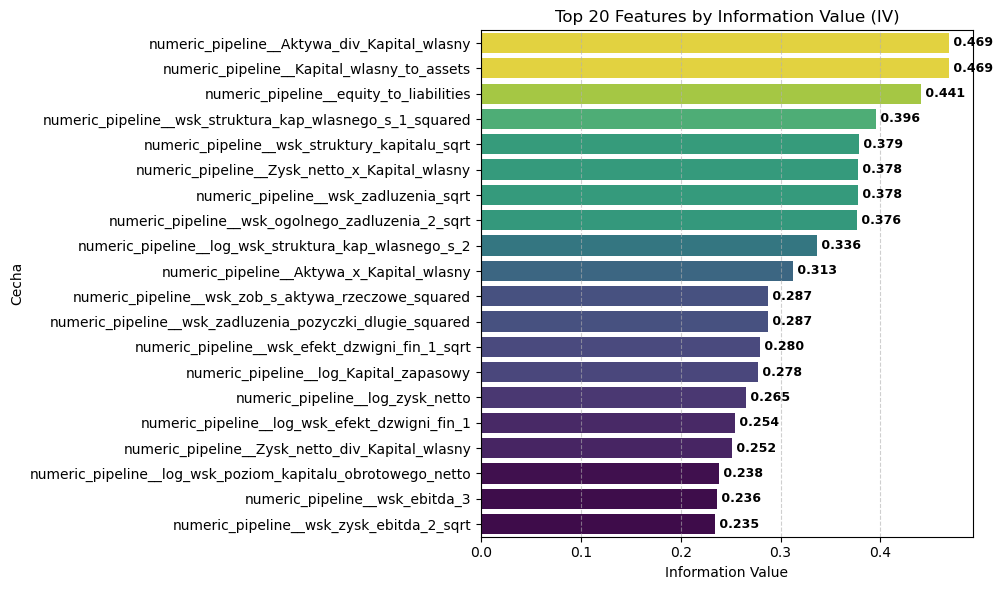

In [13]:
def calculate_iv_robust(df, feature, target):
    """
    Oblicza Information Value (IV) dla danej cechy w sposób odporny na błędy (smoothing).
    """
    df_temp = df[[feature, target]].copy()
    
    # 1. Binning (Kubełkowanie)
    try:
        # Usuwamy .rank() - niech qcut łączy powtarzające się wartości w jeden kubeł
        # Jeśli 80% ludzi ma wartość 0, wszyscy trafią do jednego kubła - i to jest OK (uczciwe)
        df_temp['bucket'] = pd.qcut(df_temp[feature], 10, duplicates='drop')
    except ValueError:
        # Fallback dla zmiennych o bardzo małej liczbie unikalnych wartości
        df_temp['bucket'] = df_temp[feature]

    # 2. Agregacja
    grouped = df_temp.groupby('bucket', observed=False)[target].agg(['count', 'sum'])
    grouped.columns = ['Total', 'Bad']
    grouped['Good'] = grouped['Total'] - grouped['Bad']
    
    # 3. Smoothing (Wygładzanie) - dodanie 0.5, by uniknąć dzielenia przez zero
    total_bad = grouped['Bad'].sum() + 0.5
    total_good = grouped['Good'].sum() + 0.5
    
    grouped['Dist_Bad'] = (grouped['Bad'] + 0.5) / total_bad
    grouped['Dist_Good'] = (grouped['Good'] + 0.5) / total_good
    
    # 4. WoE i IV
    # Logarytm ilorazu dystrybucji
    grouped['WoE'] = np.log(grouped['Dist_Good'] / grouped['Dist_Bad'])
    grouped['IV'] = (grouped['Dist_Good'] - grouped['Dist_Bad']) * grouped['WoE']
    
    return grouped['IV'].sum()

# --- ANALIZA ---
df1 = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 1. Wybór cech numerycznych (pomijając target)
top_features = df1.select_dtypes(include=[np.number]).columns.drop('default', errors='ignore').tolist()

# 2. Obliczenie IV dla wszystkich cech
iv_list = []
print(f"Rozpoczynam obliczanie IV dla {len(top_features)} cech...")

for col in top_features:
    # Pomijamy stałe kolumny (z jedną wartością), bo IV wyniesie 0 lub błąd
    if df[col].nunique() > 1:
        iv = calculate_iv_robust(df1, col, 'default')
        iv_list.append({'Feature': col, 'IV': iv})

# 3. Tworzenie ramki wyników
iv_df = pd.DataFrame(iv_list)
iv_df = iv_df.sort_values(by='IV', ascending=False).reset_index(drop=True)

# --- PREZENTACJA WYNIKÓW (TABELA + WYKRES) ---

# Liczba cech do wyświetlenia
TOP_N = 20
top_iv_df = iv_df.head(TOP_N)

# A. Wyświetlenie tabeli
print(f"\n--- TOP {TOP_N} CECH WG INFORMATION VALUE (IV) ---")
try:
    display(top_iv_df.style.background_gradient(cmap='Greens', subset=['IV']))
except NameError:
    print(top_iv_df)

# B. Wykres słupkowy
plt.figure(figsize=(10, 6))
sns.barplot(data=top_iv_df, x='IV', y='Feature', hue='IV', palette='viridis', legend=False)

plt.title(f'Top {TOP_N} Features by Information Value (IV)')
plt.xlabel('Information Value')
plt.ylabel('Cecha')
plt.grid(axis='x', linestyle='--', alpha=0.6)

for index, value in enumerate(top_iv_df['IV']):
    plt.text(value, index, f' {value:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## PCA

do celów PCA trzeba jeszcze zrobić standaryzację (zmienne o dużych wartościach zaburzą wariancję)

In [16]:
df = pd.read_csv('data/zbiór_2.csv')
y = df["default"].copy()
df = df.drop(columns='default')

transformer = dataFullTransformer(df.columns)
numeric_pipe = transformer.transformers[1][1]
numeric_pipe.set_params(dropCorrelated = 'passthrough', signCorrelationFlip='passthrough')
numeric_pipe

transf_arr = transformer.fit_transform(df, y)
df = pd.DataFrame(transf_arr, columns=transformer.get_feature_names_out())
df = pd.concat([df, y], axis=1)


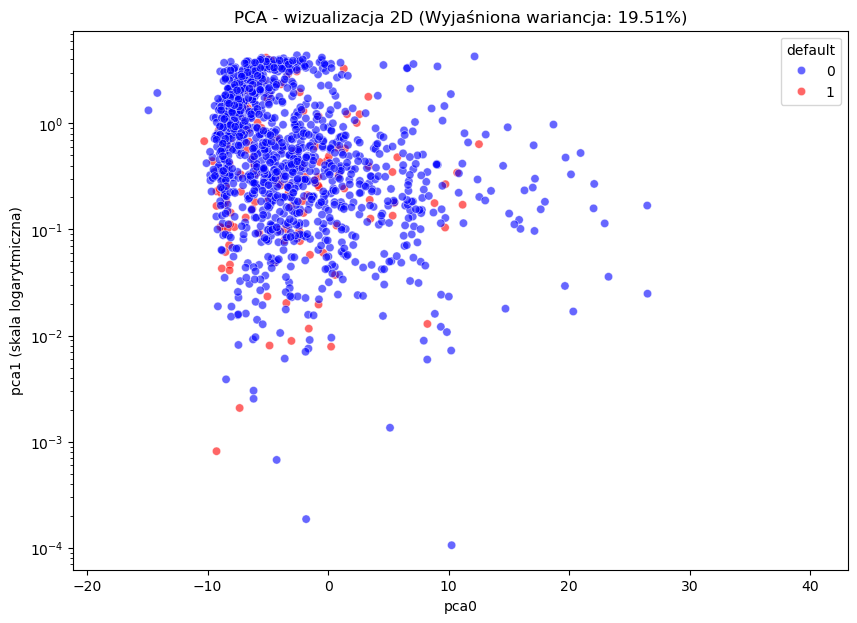

In [20]:
from sklearn.decomposition import PCA

# PCA na 2 komponenty
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df)

# Tworzenie DataFrame do wykresu
pca_df = pd.DataFrame(data=X_pca)
pca_df['default'] = y.values

# Wizualizacja
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='pca0', y='pca1', 
    hue='default', 
    data=pca_df, 
    alpha=0.6, 
    palette={0: 'blue', 1: 'red'}
)
plt.ylabel('pca1 (skala logarytmiczna)')
plt.yscale('log')
plt.title(f'PCA - wizualizacja 2D (Wyjaśniona wariancja: {pca.explained_variance_ratio_.sum():.2%})')
plt.show()

## T-SNE

Rozpoczynanie obliczeń t-SNE...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.021s...
[t-SNE] Computed neighbors for 3000 samples in 1.425s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 4.840280
[t-SNE] KL divergence after 250 iterations with early exaggeration: 73.239136
[t-SNE] KL divergence after 1000 iterations: 1.340716
t-SNE zakończone! Czas: 37.67 s


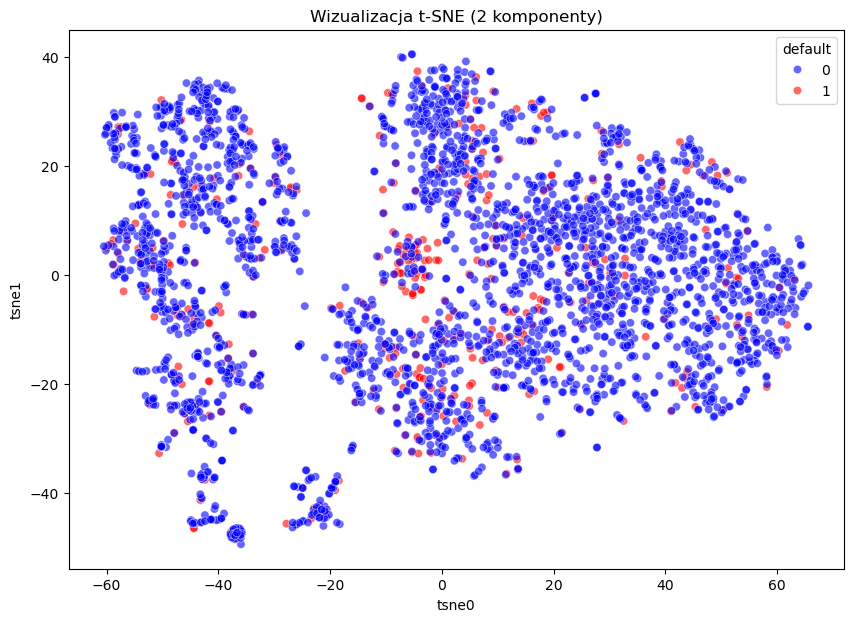

In [18]:
from sklearn.manifold import TSNE
import time

# 1. Przygotowanie danych
X = df.drop(columns='default')
y = df['default']

# Opcjonalnie: Warto najpierw zredukować wymiarowość PCA do np. 50, 
# jeśli mamy setki kolumn, aby przyspieszyć t-SNE i usunąć szum.
# from sklearn.decomposition import PCA
# X = PCA(n_components=50, random_state=42).fit_transform(X)

print("Rozpoczynanie obliczeń t-SNE...")
time_start = time.time()

# 2. Inicjalizacja i trening t-SNE
# perplexity: Kluczowy parametr (zazwyczaj 5-50). Określa, jak "lokalnie" patrzy algorytm.
tsne = TSNE(n_components=2, verbose=1, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(X)

print(f"t-SNE zakończone! Czas: {time.time()-time_start:.2f} s")

# 3. Przygotowanie DataFrame do wykresu
tsne_df = pd.DataFrame(data=tsne_results)
tsne_df['default'] = y.values

# 4. Wizualizacja
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="tsne0", y="tsne1",
    hue="default",
    palette={0: 'blue', 1: 'red'},
    data=tsne_df,
    legend="full",
    alpha=0.6
)
plt.title('Wizualizacja t-SNE (2 komponenty)')
plt.show()

In [36]:
class_counts = df['default'].value_counts(normalize=True) * 100
print(f"Procent firm, które upadły (1): {class_counts[1]:.2f}%")
print(f"Procent firm, które przetrwały (0): {class_counts[0]:.2f}%")

# Jeśli klasa 1 to < 10-15%, warto rozważyć techniki oversamplingu (SMOTE) w dalszych krokach.

Procent firm, które upadły (1): 12.97%
Procent firm, które przetrwały (0): 87.03%


# Wnioski

## 1. Jakość i Integralność Danych

### Problem Brakujących Danych (Missing Values)
* **Wniosek:** Dane finansowe są niekompletne, co jest naturalne (różne standardy raportowania). Zwykłe usuwanie wierszy doprowadziłoby do utraty cennych informacji o specyficznych podmiotach.
* **Zastosowane rozwiązanie:** Użycie `IterativeImputer` (MICE - Multivariate Imputation by Chained Equations).
* **Implikacja dla modelu:** Metoda ta jest znacznie lepsza niż proste uzupełnianie średnią, ponieważ zachowuje korelacje między wskaźnikami finansowymi. Model otrzyma spójny wielowymiarowo obraz spółki.

### Wartości Odstające (Outliers)
* **Wniosek:** Wskaźniki finansowe często przyjmują ekstremalne wartości (np. dzielenie przez bliski zeru kapitał własny), co generuje "ogony" w rozkładach.
* **Zastosowane rozwiązanie:** Winsoryzacja (Clipping) – przycięcie skrajnych percentyli.
* **Implikacja dla modelu:** Stabilizacja wariancji. Modele (szczególnie liniowe i oparte na odległościach, jak SVM czy KNN) nie będą "ściągane" przez pojedyncze anomalie, co zwiększy generalizację.

---

## 2. Struktura Zmiennej Celu (`default`)

### Niezbalansowanie Klas (Class Imbalance)
* **Obserwacja:** Liczba firm, które upadły (`default=1`), jest drastycznie mniejsza niż firm stabilnych (`default=0`).
* **Krytyczny wniosek:** Metryka **Accuracy (dokładność)** będzie bezużyteczna.
* **Rekomendacja:** Należy optymalizować model pod kątem **ROC-AUC** lub **Precision-Recall**.

---

## 3. Charakterystyka Cech (Features) i Współliniowość

### Współliniowość (Multicollinearity)
* **Wniosek:** Wskaźniki finansowe są ze sobą silnie skorelowane (wiele wskaźników bazuje na tych samych danych, np. zysku netto).
* **Ryzyko:** Nadmiarowość informacji utrudnia interpretację wpływu poszczególnych cech i może prowadzić do niestabilności modeli liniowych.
* **Rekomendacja:** Modele oparte na drzewach (XGBoost, Random Forest) poradzą sobie z tym naturalnie. W przypadku modeli liniowych konieczna będzie regularyzacja (L1/Lasso) lub redukcja wymiarowości (PCA).

### Inżynieria Cech (Feature Engineering)
* Stworzono nowe zmienne/wskaźniki (ratios), które normalizują wielkość firmy, niosąc więcej informacji niż surowe dane bilansowe.

---

## 4. Wnioski Biznesowe i Strategia Modelowania

Na podstawie EDA przyjęto następujące założenia:

1.  **Złożoność problemu:** Separacja klas nie jest liniowa. Decyduje kombinacja wielu słabych sygnałów, a nie jeden "złoty wskaźnik".
2.  **Rating jako Prawdopodobieństwo:** Wyjście modelu powinno być ciągłe (prawdopodobieństwo defaultu - PD), co pozwoli na segmentację firm na grupy ryzyka (Rating A, B, C).
3.  **Wybór Algorytmów:**
    * **Gradient Boosting (XGBoost/LightGBM):** Rekomendowane jako główne modele (odporność na braki, nieliniowość).
    * **Regresja Logistyczna (z regularyzacją):** Jako *baseline* dla porównania wyników i wyjaśnialności.
